In [11]:
import gymnasium as gym
import itertools
import math
import matplotlib
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import random
import ale_py
import tensorflow as tf
from tensorflow.keras import layers

import torch
import torch.nn as nn
import torch.optim as optim


import subprocess, sys

import numpy as np
import seaborn as sns

from tqdm import tqdm
import collections

# Make plots look nice
sns.set()
sns.set_context("notebook")
sns.set_style("whitegrid")

In [12]:
gym.register_envs(ale_py)

In [13]:
env = gym.make("ALE/Asterix-v5", obs_type="grayscale", frameskip=1)


env = gym.wrappers.AtariPreprocessing(env, frame_skip=4)
env = gym.wrappers.FrameStackObservation(env, 4)


obs, info = env.reset()


#print("Observation space:", env.observation_space)
#print("Action space:", env.action_space)

for _ in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    #print(f"obs={obs}, reward={reward:.3f}, done={terminated}")

env.close()
print("✅ All good!")

✅ All good!


In [14]:
class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)
    

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
    




Using device: cuda


In [15]:
#Empty start

episode_rewards = []
train_losses = []
step_count = 0

n_actions = env.action_space.n
Q_net = DQN(n_actions).to(device)
T_net = DQN(n_actions).to(device)
T_net.load_state_dict(Q_net.state_dict())
T_net.eval()

optimizer = optim.Adam(Q_net.parameters(), lr=1e-4)

In [16]:

def process_obs(obs):
    obs = np.array(obs, dtype=np.float32) / 255.0 
    return torch.tensor(obs, device=device).unsqueeze(0)

def train_step(obss, actions, y_vals):
    Q_net.train()
    q_vals = Q_net(obss)
    chosen_q = q_vals.gather(1, actions.unsqueeze(1)).squeeze(1)
    td_error = torch.clamp(y_vals - chosen_q, -1, 1)
    loss = (td_error ** 2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

replay_buffer = collections.deque(maxlen=100000)


In [17]:
def save_checkpoint(path, Q_net, T_net, optimizer, step_count, episode_rewards, train_losses, episode):
    torch.save({
        'episode': episode,
        'step_count': step_count,
        'Q_net': Q_net.state_dict(),
        'T_net': T_net.state_dict(),
        'optimizer': optimizer.state_dict(),
        'episode_rewards': episode_rewards,
        'train_losses': train_losses,
    }, path)
    print(f"Checkpoint saved — episode {episode}, steps {step_count}")

def load_checkpoint(path, Q_net, T_net, optimizer):
    checkpoint = torch.load(path)
    Q_net.load_state_dict(checkpoint['Q_net'])
    T_net.load_state_dict(checkpoint['T_net'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    return (
        checkpoint['step_count'],
        checkpoint['episode_rewards'],
        checkpoint['train_losses'],
        checkpoint['episode']
    )

In [ ]:
#only run this one on first go

action_space = env.action_space


print("Warming up replay buffer...")
while len(replay_buffer) < 5000:
    obs, info = env.reset()
    obs = process_obs(obs)
    done = False
    while not done and len(replay_buffer) < 5000:
        action = action_space.sample()
        next_obs, reward, terminated, truncated, info = env.step(action)
        reward = reward / 50.0
        next_obs = process_obs(next_obs)
        done = terminated or truncated
        replay_buffer.append([obs.cpu().numpy(), action, reward, next_obs.cpu().numpy(), terminated, truncated])
        obs = next_obs
print(f"Warmup done — buffer size: {len(replay_buffer)}")

In [18]:
#load start

step_count, episode_rewards, train_losses, start_episode = load_checkpoint(
    "dqn_checkpoint_ep7002.pt", Q_net, T_net, optimizer
)

In [ ]:
RESUME_WARMUP = 5000
resume_steps = 0
print("Resume warmup...")
while resume_steps < RESUME_WARMUP:
    obs, info = env.reset()
    obs = process_obs(obs)
    done = False
    while not done and resume_steps < RESUME_WARMUP:
        action = action_space.sample()
        next_obs, reward, terminated, truncated, info = env.step(action)
        reward = reward / 50.0
        next_obs = process_obs(next_obs)
        done = terminated or truncated
        replay_buffer.append([obs.cpu().numpy(), action, reward,
                               next_obs.cpu().numpy(), terminated, truncated])
        obs = next_obs
        resume_steps += 1
print("Resume warmup done")

In [ ]:
replay_buffer = collections.deque(maxlen=100000)
discount = 0.99
action_space = env.action_space


print("Refilling buffer with on-policy experience...")
while len(replay_buffer) < 50000:
    obs, info = env.reset()
    obs = process_obs(obs)
    done = False
    while not done:
        with torch.no_grad():
            action = Q_net(obs).argmax(dim=1).item()  # use trained policy
        next_obs, reward, terminated, truncated, info = env.step(action)
        reward = reward / 50.0
        next_obs = process_obs(next_obs)
        done = terminated or truncated
        replay_buffer.append([obs.cpu().numpy(), action, reward,
                               next_obs.cpu().numpy(), terminated, truncated])
        obs = next_obs
print(f"Buffer refilled: {len(replay_buffer)} transitions")


x = start_episode

for x in range(start_episode, start_episode + 2001):
    eps = max(0.1, 1.0 - step_count / 100000)

    obs, info = env.reset()
    obs = process_obs(obs)
    done = False
    total_reward = 0
    total_reward_unscaled = 0
        

    if x % 20 == 0 and x > 0:
        recent_mean = np.mean(episode_rewards[-20:])
        recent_best = np.max(episode_rewards[-20:])
        print(f"Episode {x:4d} | eps={eps:.3f} | "
              f"mean={recent_mean:.1f} | best={recent_best:.1f} | "
              f"steps={step_count}")

    while not done:
        step_count += 1

        if step_count % 5000 == 0:
            T_net.load_state_dict(Q_net.state_dict())

        if random.random() > eps:
            with torch.no_grad():
                action = Q_net(obs).argmax(dim=1).item()
        else:
            action = action_space.sample()

        next_obs, reward, terminated, truncated, info = env.step(action)
        reward = reward / 50.0
        next_obs = process_obs(next_obs)
        done = terminated or truncated

        replay_buffer.append([obs.cpu().numpy(), action, reward, next_obs.cpu().numpy(), terminated, truncated])
        total_reward += reward
        total_reward_unscaled += reward * 50
        obs = next_obs

        if len(replay_buffer) > 1000:
            replays = random.sample(replay_buffer, 64)

            obss = torch.tensor(np.vstack([r[0] for r in replays]), device=device)
            actions = torch.tensor([r[1] for r in replays], device=device, dtype=torch.long)
            rewards = torch.tensor([r[2] for r in replays], device=device, dtype=torch.float32)
            next_obss = torch.tensor(np.vstack([r[3] for r in replays]), device=device)
            dones = torch.tensor([r[4] or r[5] for r in replays], device=device, dtype=torch.float32)

            with torch.no_grad():
                q_vals = T_net(next_obss).max(dim=1).values
            y_vals = rewards + discount * q_vals * (1 - dones)

            loss = train_step(obss, actions, y_vals)
            train_losses.append(loss)

    episode_rewards.append(total_reward_unscaled)
    print(f"Episode {x}, Reward: {total_reward_unscaled:.0f}")

    if x % 500 == 0 and x > 0:
        save_checkpoint(f"dqn_checkpoint_ep{x}.pt", 
                    Q_net, T_net, optimizer, 
                    step_count, episode_rewards, train_losses, x)
        print(f"Checkpoint saved at episode {x}")

save_checkpoint(f"dqn_checkpoint_ep{x}.pt", 
                    Q_net, T_net, optimizer, 
                    step_count, episode_rewards, train_losses, x)
print(f"Checkpoint saved at episode {x}")
env.close()

Refilling buffer with on-policy experience...
Buffer refilled: 50011 transitions
Episode 7002, Reward: 600
Episode 7003, Reward: 600
Episode 7004, Reward: 250
Episode 7005, Reward: 850
Episode 7006, Reward: 900
Episode 7007, Reward: 550
Episode 7008, Reward: 900
Episode 7009, Reward: 300
Episode 7010, Reward: 300
Episode 7011, Reward: 450
Episode 7012, Reward: 150
Episode 7013, Reward: 700
Episode 7014, Reward: 950
Episode 7015, Reward: 300
Episode 7016, Reward: 650
Episode 7017, Reward: 800
Episode 7018, Reward: 300
Episode 7019, Reward: 350
Episode 7020 | eps=0.100 | mean=515.0 | best=950.0 | steps=2064422
Episode 7020, Reward: 600
Episode 7021, Reward: 650
Episode 7022, Reward: 500
Episode 7023, Reward: 250
Episode 7024, Reward: 400
Episode 7025, Reward: 450
Episode 7026, Reward: 900
Episode 7027, Reward: 350
Episode 7028, Reward: 350
Episode 7029, Reward: 550
Episode 7030, Reward: 850
Episode 7031, Reward: 350
Episode 7032, Reward: 300
Episode 7033, Reward: 300
Episode 7034, Reward

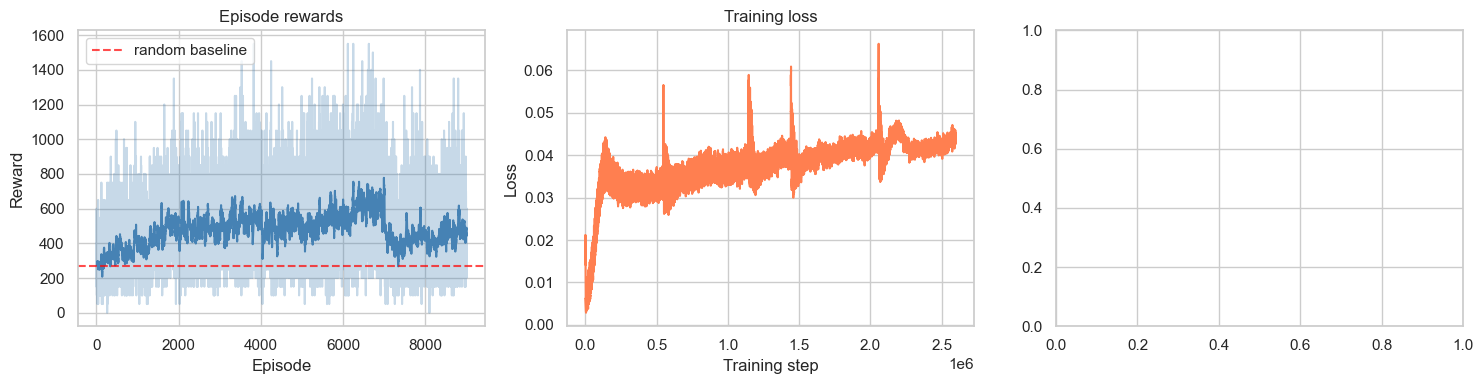

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def evaluate_agent(env, Q_net, device, n_episodes=20, eps=0.0):
    """Run n_episodes and return rewards. eps=0 for pure greedy, eps=0.05 for slight exploration."""
    Q_net.eval()
    rewards = []
    
    for ep in range(n_episodes):
        obs, info = env.reset()
        obs_t = process_obs(obs)
        done = False
        total = 0
        
        while not done:
            if random.random() > eps:
                with torch.no_grad():
                    action = Q_net(obs_t).argmax(dim=1).item()
            else:
                action = env.action_space.sample()
                
            obs, reward, terminated, truncated, info = env.step(action)
            obs_t = process_obs(obs)
            total += reward
            done = terminated or truncated
            
        rewards.append(total)
    
    Q_net.train()
    return rewards


def plot_training(episode_rewards, train_losses, eval_scores=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Raw + smoothed episode rewards
    rewards = np.array(episode_rewards)
    axes[0].plot(rewards, alpha=0.3, color='steelblue')
    if len(rewards) >= 20:
        smoothed = np.convolve(rewards, np.ones(20)/20, mode='valid')
        axes[0].plot(range(19, len(rewards)), smoothed, color='steelblue')
    axes[0].axhline(y=267, color='red', linestyle='--', alpha=0.7, label='random baseline')
    axes[0].set_title('Episode rewards')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Reward')
    axes[0].legend()
    
    # Smoothed loss
    if len(train_losses) > 0:
        losses = np.array(train_losses)
        if len(losses) >= 1000:
            smoothed_loss = np.convolve(losses, np.ones(1000)/1000, mode='valid')
            axes[1].plot(smoothed_loss, color='coral')
        else:
            axes[1].plot(losses, color='coral')
    axes[1].set_title('Training loss')
    axes[1].set_xlabel('Training step')
    axes[1].set_ylabel('Loss')
    
    # Periodic eval scores
    if eval_scores and len(eval_scores) > 0:
        eval_means = [np.mean(s) for s in eval_scores]
        eval_stds  = [np.std(s)  for s in eval_scores]
        x = range(len(eval_means))
        axes[2].plot(eval_means, color='green')
        axes[2].fill_between(x,
            np.array(eval_means) - np.array(eval_stds),
            np.array(eval_means) + np.array(eval_stds),
            alpha=0.2, color='green')
        axes[2].axhline(y=267, color='red', linestyle='--', alpha=0.7, label='random baseline')
        axes[2].set_title('Eval score over time')
        axes[2].set_xlabel('Eval checkpoint')
        axes[2].set_ylabel('Mean reward')
        axes[2].legend()
    
    plt.tight_layout()
    plt.show()


# Add this list before your training loop
eval_scores = []

# Add this block inside your training loop every 200 episodes
#if x % 200 == 0 and x > 0:
    #scores = evaluate_agent(env, Q_net, device, n_episodes=10)
    #eval_scores.append(scores)
    #print(f"--- Eval at episode {x} | "
          #f"mean={np.mean(scores):.1f} | "
          #f"std={np.std(scores):.1f} | "
          #f"best={np.max(scores):.1f} | "
          #f"vs random=267 ---")

# Call this whenever you want to see the full picture
plot_training(episode_rewards, train_losses, eval_scores)

In [37]:
# Check what's actually happening in one episode
obs, info = env.reset()
obs = process_obs(obs)
done = False
steps = 0
while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    obs = process_obs(obs)
    steps += 1
    done = terminated or truncated
    if steps < 5:
        print(f"step={steps} reward={reward} terminated={terminated} truncated={truncated}")

print(f"Episode ended after {steps} steps")

step=1 reward=0.0 terminated=False truncated=False
step=2 reward=0.0 terminated=False truncated=False
step=3 reward=0.0 terminated=False truncated=False
step=4 reward=0.0 terminated=False truncated=False
Episode ended after 291 steps


In [ ]:
# Run this on a fixed batch of states
def check_q_magnitude(Q_net, replay_buffer, device, n=500):
    sample = random.sample(replay_buffer, n)
    obss = torch.tensor(np.vstack([r[0] for r in sample]), device=device)
    with torch.no_grad():
        q_vals = Q_net(obss).max(dim=1).values
    print(f"Mean max-Q: {q_vals.mean().item():.3f}")
    print(f"Max  max-Q: {q_vals.max().item():.3f}")

check_q_magnitude(Q_net, replay_buffer, device)

Mean max-Q: 7.178
Max  max-Q: 12.631


: 